**Task 1:**
Identify data quality issues in the dataset.

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [3]:
df = pd.read_csv("StudentsPerformance.csv")

In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [7]:
print(df.isnull().sum()) # check missing values

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [8]:
print("Duplicates:", df.duplicated().sum()) # check duplicates

Duplicates: 0


In [10]:
df.describe() # show basic description 

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


we can observe that there are no signs of missing values or duplicates. 

**Task 2:**
Apply one missing value strategy and explain why.

In [15]:
df.fillna({
    'math score': df['math score'].mean(),
    'reading score': df['reading score'].mean(),
    'writing score': df['writing score'].mean()
}, inplace=True)

In [16]:
df.isnull().sum() # to show that the above method works

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

**Task 3:**
Detect and handle outliers using IQR.

In [17]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

for col in ['math score', 'reading score', 'writing score']:
    df = remove_outliers(df, col)
df.shape

(986, 8)

**Task 4:**
Normalize numerical features using both Min-Max and Z-score.

In [19]:
# min , max scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_minmax = df.copy()
df_minmax[['math score', 'reading score', 'writing score']] = scaler.fit_transform(
    df[['math score', 'reading score', 'writing score']]
)

df_minmax.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,0.616438,0.594203,0.617647
1,female,group C,some college,standard,completed,0.575342,0.855072,0.823529
2,female,group B,master's degree,standard,none,0.863014,0.927536,0.897059
3,male,group A,associate's degree,free/reduced,none,0.273973,0.376812,0.176471
4,male,group C,some college,standard,none,0.671233,0.681159,0.632353


In [20]:
# z score normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_zscore = df.copy()
df_zscore[['math score', 'reading score', 'writing score']] = scaler.fit_transform(
    df[['math score', 'reading score', 'writing score']]
)

df_zscore.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,0.370131,0.163761,0.371152
1,female,group C,some college,standard,completed,0.160831,1.458384,1.342041
2,female,group B,master's degree,standard,none,1.625930,1.818002,1.688787
3,male,group A,associate's degree,free/reduced,none,-1.374034,-0.915092,-1.709324
4,male,group C,some college,standard,none,0.649197,0.595302,0.440501


**Task 5:**
Apply PCA only if the numerical features show a correlation.

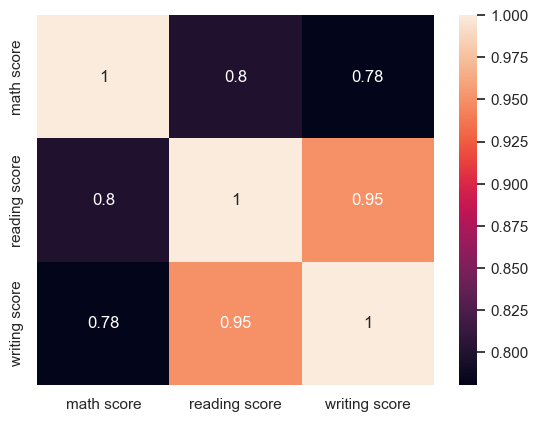

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df[['math score', 'reading score', 'writing score']].corr(), annot=True)
plt.show()

In [ ]:
it shows a strong correlation, therfore pca can be applied